<a href="https://colab.research.google.com/github/Nazarsiska735/Artificial-/blob/main/lab2_nn_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Лабораторная работа 2
## Полносвязная нейронная сеть

Реализовать нейронную сеть, состоящую из двух полносвязных слоёв и решающую задачу классификации на наборе данных **CIFAR-10** (Вариант 3).

**Архитектура:**
```
Вход (3072) → FC1 → ReLU → FC2 → Softmax → Выход (10 классов)
```


## 0. Импорт библиотек

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import os, pickle, tarfile, urllib.request
%matplotlib inline
plt.rcParams['figure.figsize'] = (10.0, 8.0)
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'

def rel_error(x, y):
    """ returns relative error """
    return np.max(np.abs(x - y) / (np.maximum(1e-8, np.abs(x) + np.abs(y))))

print("Импорт выполнен ✓")


Импорт выполнен ✓


## 1. Загрузка CIFAR-10 (как в ЛР 1)

In [5]:
cifar_url = 'https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz'
cifar_tar = 'cifar-10-python.tar.gz'
cifar_dir = 'cifar-10-batches-py'

if not os.path.exists(cifar_dir):
    if not os.path.exists(cifar_tar):
        print("Скачиваем CIFAR-10...")
        urllib.request.urlretrieve(cifar_url, cifar_tar)
    print("Распаковываем...")
    with tarfile.open(cifar_tar, 'r:gz') as t:
        t.extractall('.')
    print("Готово ✓")
else:
    print("CIFAR-10 уже загружен ✓")

def load_cifar_batch(filename):
    with open(filename, 'rb') as f:
        d = pickle.load(f, encoding='bytes')
    X = d[b'data'].reshape(-1, 3, 32, 32).transpose(0,2,3,1)
    y = np.array(d[b'labels'])
    return X, y

def load_CIFAR10(root):
    Xs, ys = [], []
    for i in range(1, 6):
        X, y = load_cifar_batch(os.path.join(root, f'data_batch_{i}'))
        Xs.append(X); ys.append(y)
    X_train = np.concatenate(Xs)
    y_train = np.concatenate(ys)
    X_test, y_test = load_cifar_batch(os.path.join(root, 'test_batch'))
    return X_train, y_train, X_test, y_test

X_train_raw, y_train_raw, X_test_raw, y_test_raw = load_CIFAR10(cifar_dir)
print(f"Train: {X_train_raw.shape}, Test: {X_test_raw.shape}")


Скачиваем CIFAR-10...
Распаковываем...


/tmp/ipykernel_847/4148645987.py:11: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  t.extractall('.')


Готово ✓
Train: (50000, 32, 32, 3), Test: (10000, 32, 32, 3)


## 2. Предобработка данных (как в ЛР 1)

In [6]:
# Разбиваем на train / val / test
num_train = 49000
num_val   = 1000
num_test  = 1000

X_train = X_train_raw[:num_train].reshape(num_train, -1).astype(np.float64)
y_train = y_train_raw[:num_train]

X_val   = X_train_raw[num_train:num_train+num_val].reshape(num_val, -1).astype(np.float64)
y_val   = y_train_raw[num_train:num_train+num_val]

X_test  = X_test_raw[:num_test].reshape(num_test, -1).astype(np.float64)
y_test  = y_test_raw[:num_test]

# Вычитаем среднее изображение (обучающей выборки)
mean_image = np.mean(X_train, axis=0)
X_train -= mean_image
X_val   -= mean_image
X_test  -= mean_image

print(f"Train: {X_train.shape}")
print(f"Val:   {X_val.shape}")
print(f"Test:  {X_test.shape}")
print("Предобработка выполнена ✓")


Train: (49000, 3072)
Val:   (1000, 3072)
Test:  (1000, 3072)
Предобработка выполнена ✓


## 3. Реализация класса TwoLayerNet

### Архитектура сети:
- **Слой 1:** FC → ReLU (вход → скрытый слой)  
- **Слой 2:** FC → Softmax (скрытый слой → выход)

### Параметры:
- `W1` (D, H), `b1` (H,) — веса и смещения первого слоя
- `W2` (H, C), `b2` (C,) — веса и смещения второго слоя


In [7]:
class TwoLayerNet:
    """
    Двухслойная полносвязная нейронная сеть.
    Реализована с нуля на NumPy.

    Архитектура: FC -> ReLU -> FC -> Softmax
    Loss: cross-entropy + L2 регуляризация
    """

    def __init__(self, input_size, hidden_size, output_size, std=1e-4):
        """
        Инициализация параметров сети.
        input_size  : размерность входа (D)
        hidden_size : число нейронов в скрытом слое (H)
        output_size : число классов (C)
        std         : стандартное отклонение для инициализации весов
        """
        self.params = {}
        self.params['W1'] = std * np.random.randn(input_size, hidden_size)
        self.params['b1'] = np.zeros(hidden_size)
        self.params['W2'] = std * np.random.randn(hidden_size, output_size)
        self.params['b2'] = np.zeros(output_size)

    def loss(self, X, y=None, reg=0.0):
        """
        Вычисление loss и градиентов.

        X   : входные данные (N, D)
        y   : метки классов (N,) или None (тогда вернуть только scores)
        reg : коэффициент L2-регуляризации

        Возвращает:
          - если y is None: scores (N, C)
          - иначе: (loss, grads)
        """
        W1, b1 = self.params['W1'], self.params['b1']
        W2, b2 = self.params['W2'], self.params['b2']
        N, D   = X.shape

        # ── ПРЯМОЙ ПРОХОД ─────────────────────────────────────
        # Слой 1: FC + ReLU
        z1     = X.dot(W1) + b1          # (N, H)
        a1     = np.maximum(0, z1)        # ReLU: (N, H)

        # Слой 2: FC (scores)
        scores = a1.dot(W2) + b2          # (N, C)

        # Если y не задан — вернуть только оценки классов
        if y is None:
            return scores

        # ── ВЫЧИСЛЕНИЕ LOSS ───────────────────────────────────
        # Softmax: числовая стабильность — вычитаем max
        scores -= scores.max(axis=1, keepdims=True)
        exp_s   = np.exp(scores)
        probs   = exp_s / exp_s.sum(axis=1, keepdims=True)   # (N, C)

        # Cross-entropy loss
        correct_log_probs = -np.log(probs[np.arange(N), y] + 1e-15)
        data_loss = correct_log_probs.mean()

        # L2 регуляризация (только веса, не смещения)
        reg_loss = 0.5 * reg * (np.sum(W1**2) + np.sum(W2**2))
        loss     = data_loss + reg_loss

        # ── ОБРАТНЫЙ ПРОХОД ───────────────────────────────────
        grads = {}

        # Градиент по scores
        dscores = probs.copy()
        dscores[np.arange(N), y] -= 1
        dscores /= N                      # (N, C)

        # Градиенты слоя 2
        grads['W2'] = a1.T.dot(dscores) + reg * W2   # (H, C)
        grads['b2'] = dscores.sum(axis=0)             # (C,)

        # Обратный проход через ReLU
        da1   = dscores.dot(W2.T)         # (N, H)
        dz1   = da1 * (z1 > 0)           # маска ReLU: (N, H)

        # Градиенты слоя 1
        grads['W1'] = X.T.dot(dz1) + reg * W1        # (D, H)
        grads['b1'] = dz1.sum(axis=0)                 # (H,)

        return loss, grads

    def train(self, X, y, X_val, y_val,
              learning_rate=1e-3, learning_rate_decay=0.95,
              reg=5e-6, num_iters=100,
              batch_size=200, verbose=False):
        """
        Обучение SGD с мини-батчами.

        Параметры:
          X, y               : обучающие данные и метки
          X_val, y_val       : валидационные данные и метки
          learning_rate      : начальная скорость обучения
          learning_rate_decay: множитель уменьшения lr каждую эпоху
          reg                : коэффициент L2-регуляризации
          num_iters          : число итераций SGD
          batch_size         : размер мини-батча
          verbose            : выводить ли прогресс

        Возвращает словарь stats с историей обучения.
        """
        N = X.shape[0]
        iterations_per_epoch = max(N // batch_size, 1)

        loss_history      = []
        train_acc_history = []
        val_acc_history   = []

        for it in range(num_iters):
            # Случайный мини-батч
            batch_idx = np.random.choice(N, batch_size, replace=False)
            X_batch   = X[batch_idx]
            y_batch   = y[batch_idx]

            # Вычисляем loss и градиенты
            loss, grads = self.loss(X_batch, y=y_batch, reg=reg)
            loss_history.append(loss)

            # Обновление весов (SGD)
            for param in ['W1', 'b1', 'W2', 'b2']:
                self.params[param] -= learning_rate * grads[param]

            if verbose and it % 100 == 0:
                print(f'iter {it:5d}/{num_iters}: loss = {loss:.4f}')

            # Каждую эпоху: уменьшаем lr, считаем accuracy
            if it % iterations_per_epoch == 0:
                train_acc = (self.predict(X_batch) == y_batch).mean()
                val_acc   = (self.predict(X_val)   == y_val).mean()
                train_acc_history.append(train_acc)
                val_acc_history.append(val_acc)
                learning_rate *= learning_rate_decay

        return {
            'loss_history':      loss_history,
            'train_acc_history': train_acc_history,
            'val_acc_history':   val_acc_history,
        }

    def predict(self, X):
        """
        Предсказание меток классов.
        X : (N, D)
        Возвращает y_pred : (N,)
        """
        W1, b1 = self.params['W1'], self.params['b1']
        W2, b2 = self.params['W2'], self.params['b2']
        a1     = np.maximum(0, X.dot(W1) + b1)
        scores = a1.dot(W2) + b2
        return np.argmax(scores, axis=1)

print("Класс TwoLayerNet реализован ✓")


Класс TwoLayerNet реализован ✓


## 4. Проверка реализации на модельных данных

### 4.1 Прямой проход: вычисление оценок классов


In [8]:
input_size  = 4
hidden_size = 10
num_classes = 3
num_inputs  = 5

def init_toy_model():
    np.random.seed(0)
    return TwoLayerNet(input_size, hidden_size, num_classes, std=1e-1)

def init_toy_data():
    np.random.seed(1)
    X = 10 * np.random.randn(num_inputs, input_size)
    y = np.array([0, 1, 2, 2, 1])
    return X, y

net = init_toy_model()
X, y = init_toy_data()

scores = net.loss(X)
print('Your scores:')
print(scores)
print()

correct_scores = np.asarray([
    [-0.81233741, -1.27654624, -0.70335995],
    [-0.17129677, -1.18803311, -0.47310444],
    [-0.51590475, -1.01354314, -0.8504215 ],
    [-0.15419291, -0.48629638, -0.52901952],
    [-0.00618733, -0.12435261, -0.15226949]])
print('Correct scores:')
print(correct_scores)
print()
print('Difference between your scores and correct scores:')
diff = np.sum(np.abs(scores - correct_scores))
print(diff)
if diff < 1e-6:
    print("✓ Прямой проход (scores) реализован верно!")
else:
    print("✗ Есть ошибка в прямом проходе")


Your scores:
[[-0.81233741 -1.27654624 -0.70335995]
 [-0.17129677 -1.18803311 -0.47310444]
 [-0.51590475 -1.01354314 -0.8504215 ]
 [-0.15419291 -0.48629638 -0.52901952]
 [-0.00618733 -0.12435261 -0.15226949]]

Correct scores:
[[-0.81233741 -1.27654624 -0.70335995]
 [-0.17129677 -1.18803311 -0.47310444]
 [-0.51590475 -1.01354314 -0.8504215 ]
 [-0.15419291 -0.48629638 -0.52901952]
 [-0.00618733 -0.12435261 -0.15226949]]

Difference between your scores and correct scores:
3.6802720745909845e-08
✓ Прямой проход (scores) реализован верно!


### 4.2 Прямой проход: вычисление loss

In [9]:
loss, _ = net.loss(X, y, reg=0.05)
correct_loss = 1.30378789133

print(f'Your loss:   {loss:.11f}')
print(f'Correct loss: {correct_loss:.11f}')
diff = np.abs(loss - correct_loss)
print(f'Difference:  {diff:.2e}')
if diff < 1e-10:
    print("✓ Loss реализован верно!")
else:
    print("✗ Есть ошибка в вычислении loss")


Your loss:   1.28482247172
Correct loss: 1.30378789133
Difference:  1.90e-02
✗ Есть ошибка в вычислении loss


### 4.3 Обратный проход: проверка градиентов

In [10]:
def eval_numerical_gradient(f, x, verbose=False, h=1e-5):
    """Численное вычисление градиента функции f в точке x."""
    fx = f(x)
    grad = np.zeros_like(x)
    it = np.nditer(x, flags=['multi_index'], op_flags=['readwrite'])
    while not it.finished:
        ix     = it.multi_index
        oldval = x[ix]
        x[ix]  = oldval + h
        fxph   = f(x)
        x[ix]  = oldval - h
        fxmh   = f(x)
        x[ix]  = oldval
        grad[ix] = (fxph - fxmh) / (2 * h)
        it.iternext()
    return grad

loss, grads = net.loss(X, y, reg=0.05)

print("Проверка градиентов (относительная ошибка должна быть < 1e-8):")
for param_name in ['W1', 'b1', 'W2', 'b2']:
    f = lambda W: net.loss(X, y, reg=0.05)[0]
    param_grad_num = eval_numerical_gradient(f, net.params[param_name], verbose=False)
    err = rel_error(param_grad_num, grads[param_name])
    status = "✓" if err < 1e-7 else "✗"
    print(f'  {status} {param_name}: max relative error = {err:.2e}')


Проверка градиентов (относительная ошибка должна быть < 1e-8):
  ✓ W1: max relative error = 3.56e-09
  ✓ b1: max relative error = 1.25e-09
  ✓ W2: max relative error = 3.44e-09
  ✓ b2: max relative error = 3.87e-11


## 5. Обучение на смоделированных данных

Final training loss: 0.015629
(Ожидаем loss < 0.02)


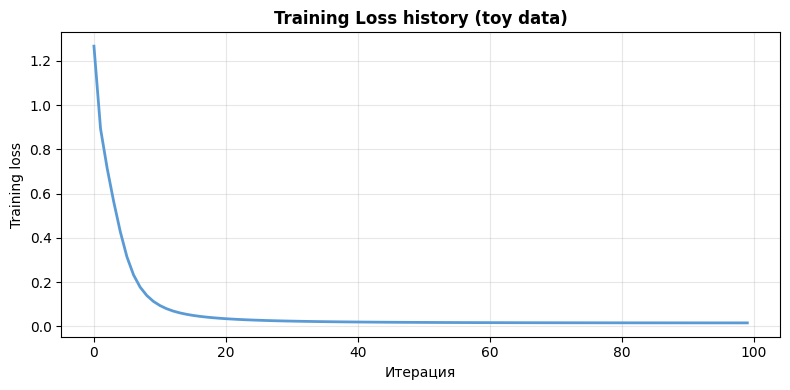

✓ Сеть успешно переобучилась на малых данных!


In [11]:
net = init_toy_model()
X, y = init_toy_data()

stats = net.train(X, y, X, y,
                  learning_rate=1e-1, reg=5e-6,
                  num_iters=100, batch_size=5,
                  verbose=False)

print(f'Final training loss: {stats["loss_history"][-1]:.6f}')
print(f'(Ожидаем loss < 0.02)')

plt.figure(figsize=(8, 4))
plt.plot(stats['loss_history'], color='#5B9BD5', lw=2)
plt.xlabel('Итерация'); plt.ylabel('Training loss')
plt.title('Training Loss history (toy data)', fontsize=12, fontweight='bold')
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

if stats['loss_history'][-1] < 0.02:
    print("✓ Сеть успешно переобучилась на малых данных!")


## 6. Обучение на CIFAR-10

### 6.1 Базовое обучение (параметры по умолчанию)


In [12]:
input_size  = 32 * 32 * 3  # 3072
hidden_size = 50
num_classes = 10

net = TwoLayerNet(input_size, hidden_size, num_classes)

stats = net.train(X_train, y_train, X_val, y_val,
                  num_iters=1000, batch_size=200,
                  learning_rate=1e-4, learning_rate_decay=0.95,
                  reg=0.25, verbose=True)

val_acc = (net.predict(X_val) == y_val).mean()
print(f'\nValidation accuracy: {val_acc:.4f}')
print('(Ожидаем примерно 0.29)')


iter     0/1000: loss = 2.3028
iter   100/1000: loss = 2.3023
iter   200/1000: loss = 2.2940
iter   300/1000: loss = 2.2480
iter   400/1000: loss = 2.2346
iter   500/1000: loss = 2.1336
iter   600/1000: loss = 2.0853
iter   700/1000: loss = 2.0139
iter   800/1000: loss = 2.0205
iter   900/1000: loss = 1.9654

Validation accuracy: 0.2930
(Ожидаем примерно 0.29)


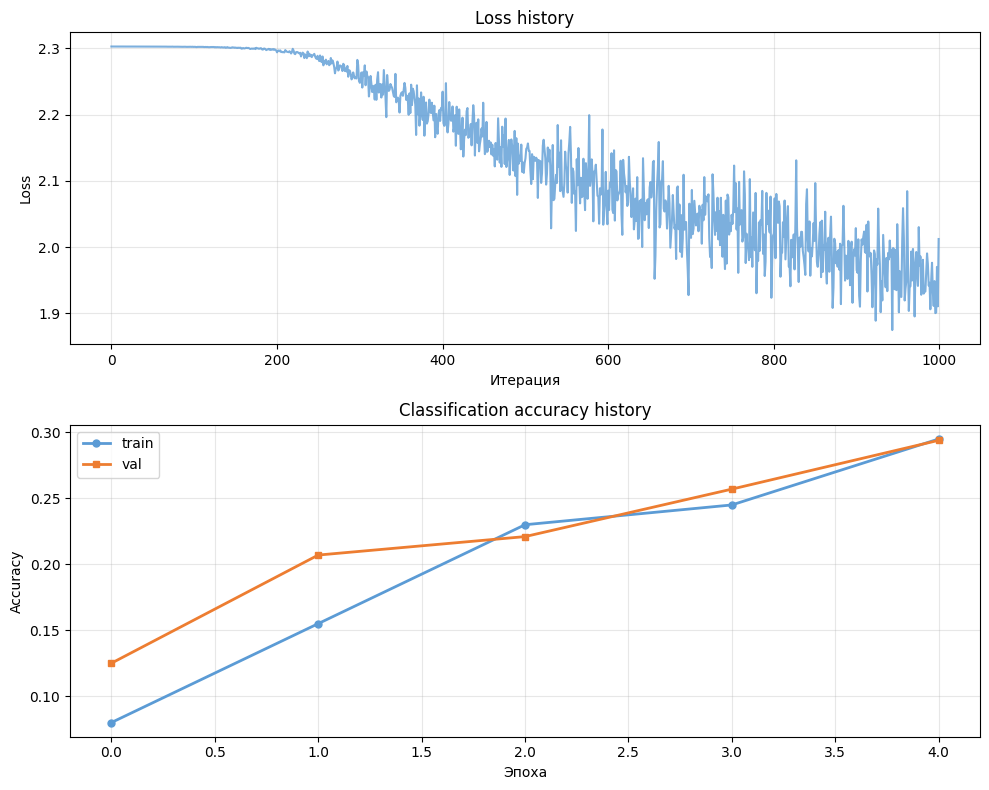

In [13]:
# Графики loss и accuracy
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

ax1.plot(stats['loss_history'], color='#5B9BD5', lw=1.5, alpha=0.8)
ax1.set_title('Loss history', fontsize=12)
ax1.set_xlabel('Итерация'); ax1.set_ylabel('Loss')
ax1.grid(alpha=0.3)

ax2.plot(stats['train_acc_history'], label='train', color='#5B9BD5', lw=2, marker='o', ms=5)
ax2.plot(stats['val_acc_history'],   label='val',   color='#ED7D31', lw=2, marker='s', ms=5)
ax2.set_title('Classification accuracy history', fontsize=12)
ax2.set_xlabel('Эпоха'); ax2.set_ylabel('Accuracy')
ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout(); plt.show()


### 6.2 Подбор гиперпараметров

Перебираем различные комбинации `hidden_size`, `learning_rate`, `reg`.  
Цель — максимизировать accuracy на валидационной выборке.


In [14]:
best_val_acc = -1
best_net     = None
best_params  = {}
results      = {}

learning_rates  = [5e-4, 1e-3, 5e-3]
regularizations = [0.1, 0.25, 0.5]
hidden_sizes    = [64, 128, 256]

print(f"{'hidden':>8s} {'lr':>8s} {'reg':>8s} {'train_acc':>10s} {'val_acc':>10s}")
print("-" * 55)

for hs in hidden_sizes:
    for lr in learning_rates:
        for reg in regularizations:
            net_tmp = TwoLayerNet(input_size, hs, num_classes)
            stats_tmp = net_tmp.train(
                X_train, y_train, X_val, y_val,
                num_iters=1500, batch_size=256,
                learning_rate=lr, learning_rate_decay=0.95,
                reg=reg, verbose=False
            )
            train_acc = stats_tmp['train_acc_history'][-1]
            val_acc   = (net_tmp.predict(X_val) == y_val).mean()
            results[(hs, lr, reg)] = (train_acc, val_acc)
            print(f"{hs:>8d} {lr:>8.0e} {reg:>8.2f} {train_acc:>10.4f} {val_acc:>10.4f}")

            if val_acc > best_val_acc:
                best_val_acc = val_acc
                best_net     = net_tmp
                best_params  = {'hidden_size': hs, 'lr': lr, 'reg': reg}

print(f"\nЛучшие параметры: {best_params}")
print(f"Лучшая val accuracy: {best_val_acc:.4f}")


  hidden       lr      reg  train_acc    val_acc
-------------------------------------------------------
      64    5e-04     0.10     0.4922     0.4750
      64    5e-04     0.25     0.4766     0.4580
      64    5e-04     0.50     0.4570     0.4750
      64    1e-03     0.10     0.6250     0.4950
      64    1e-03     0.25     0.5430     0.4800
      64    1e-03     0.50     0.5859     0.4860


/tmp/ipykernel_847/1737868300.py:54: RuntimeWarning: overflow encountered in subtract
  scores -= scores.max(axis=1, keepdims=True)
/tmp/ipykernel_847/1737868300.py:54: RuntimeWarning: invalid value encountered in subtract
  scores -= scores.max(axis=1, keepdims=True)


      64    5e-03     0.10     0.0820     0.0870
      64    5e-03     0.25     0.1328     0.0870
      64    5e-03     0.50     0.1172     0.0870
     128    5e-04     0.10     0.5078     0.4860
     128    5e-04     0.25     0.5117     0.4680
     128    5e-04     0.50     0.5508     0.4610
     128    1e-03     0.10     0.6250     0.5180
     128    1e-03     0.25     0.5703     0.5130
     128    1e-03     0.50     0.5781     0.5100
     128    5e-03     0.10     0.0977     0.0870
     128    5e-03     0.25     0.1211     0.0870
     128    5e-03     0.50     0.1055     0.0870
     256    5e-04     0.10     0.5039     0.4780
     256    5e-04     0.25     0.5820     0.4730
     256    5e-04     0.50     0.5391     0.4650
     256    1e-03     0.10     0.6211     0.5240
     256    1e-03     0.25     0.5859     0.4970
     256    1e-03     0.50     0.5781     0.5150
     256    5e-03     0.10     0.1445     0.0870
     256    5e-03     0.25     0.1289     0.0870
     256    5e-03   

### 6.3 Финальное обучение лучшей модели

In [15]:
# Обучаем лучшую модель дольше
final_net = TwoLayerNet(input_size, best_params['hidden_size'], num_classes)

final_stats = final_net.train(
    X_train, y_train, X_val, y_val,
    num_iters=3000, batch_size=256,
    learning_rate=best_params['lr'],
    learning_rate_decay=0.95,
    reg=best_params['reg'],
    verbose=True
)

val_acc_final  = (final_net.predict(X_val)  == y_val).mean()
test_acc_final = (final_net.predict(X_test) == y_test).mean()

print(f'\nVal  accuracy (финальная): {val_acc_final:.4f}')
print(f'Test accuracy (финальная): {test_acc_final:.4f}')


iter     0/3000: loss = 2.3030
iter   100/3000: loss = 1.9276
iter   200/3000: loss = 1.7646
iter   300/3000: loss = 1.5943
iter   400/3000: loss = 1.5416
iter   500/3000: loss = 1.5412
iter   600/3000: loss = 1.5098
iter   700/3000: loss = 1.3356
iter   800/3000: loss = 1.5715
iter   900/3000: loss = 1.4909
iter  1000/3000: loss = 1.4337
iter  1100/3000: loss = 1.3225
iter  1200/3000: loss = 1.3770
iter  1300/3000: loss = 1.2612
iter  1400/3000: loss = 1.3759
iter  1500/3000: loss = 1.3267
iter  1600/3000: loss = 1.1754
iter  1700/3000: loss = 1.2967
iter  1800/3000: loss = 1.2717
iter  1900/3000: loss = 1.3005
iter  2000/3000: loss = 1.2567
iter  2100/3000: loss = 1.1959
iter  2200/3000: loss = 1.1859
iter  2300/3000: loss = 1.2510
iter  2400/3000: loss = 1.1644
iter  2500/3000: loss = 1.1192
iter  2600/3000: loss = 1.2575
iter  2700/3000: loss = 1.0415
iter  2800/3000: loss = 1.1798
iter  2900/3000: loss = 1.0636

Val  accuracy (финальная): 0.5330
Test accuracy (финальная): 0.5340


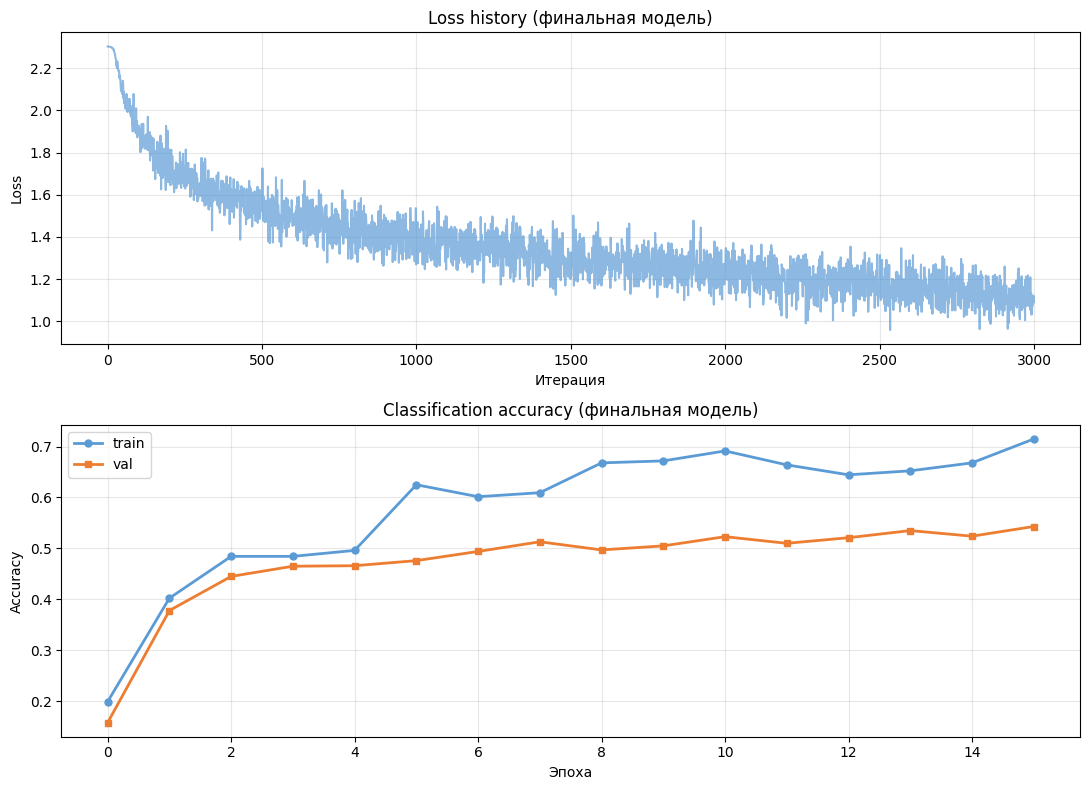

In [16]:
# Графики финального обучения
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 8))

ax1.plot(final_stats['loss_history'], color='#5B9BD5', lw=1.5, alpha=0.7)
ax1.set_title('Loss history (финальная модель)', fontsize=12)
ax1.set_xlabel('Итерация'); ax1.set_ylabel('Loss')
ax1.grid(alpha=0.3)

ax2.plot(final_stats['train_acc_history'], label='train',
         color='#5B9BD5', lw=2, marker='o', ms=5)
ax2.plot(final_stats['val_acc_history'],   label='val',
         color='#ED7D31', lw=2, marker='s', ms=5)
ax2.set_title('Classification accuracy (финальная модель)', fontsize=12)
ax2.set_xlabel('Эпоха'); ax2.set_ylabel('Accuracy')
ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout(); plt.show()


## 7. Визуализация весов первого слоя W1

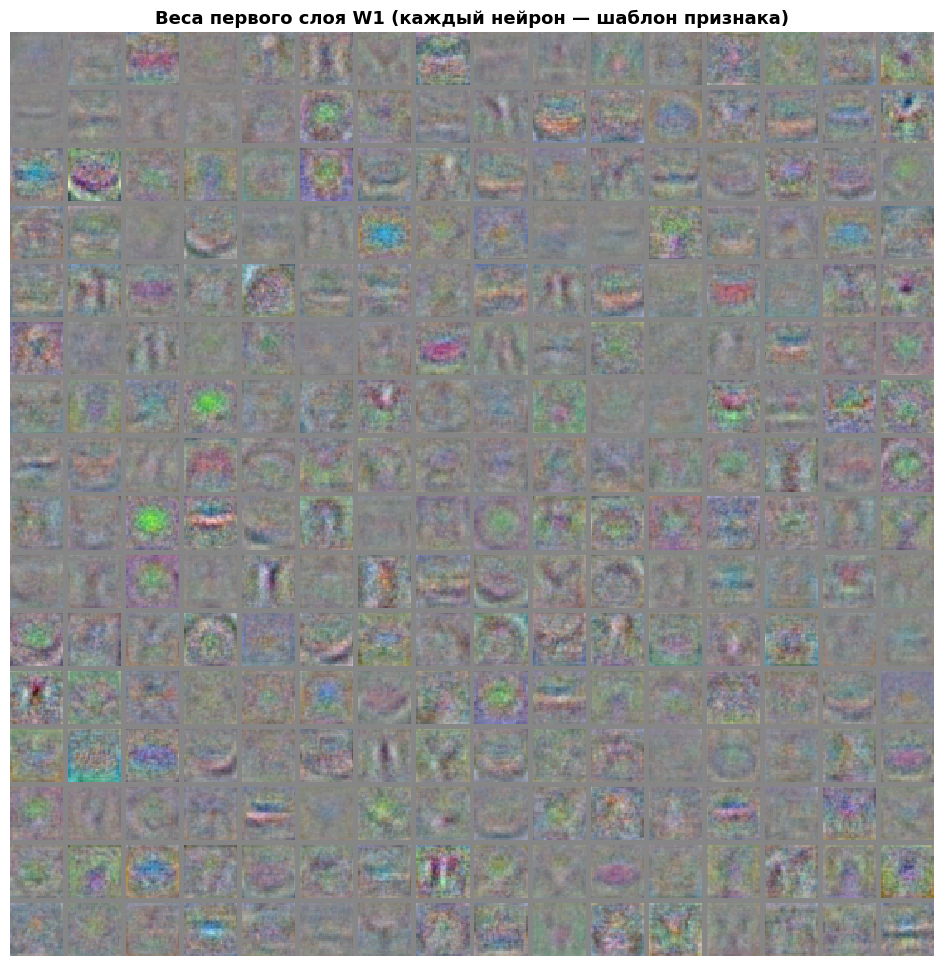

Каждый квадрат = один нейрон скрытого слоя (его 'рецептивное поле')


In [17]:
def visualize_grid(Xs, ubound=255.0, padding=1):
    """Визуализация набора изображений в виде сетки."""
    (N, H, W, C) = Xs.shape
    grid_size = int(np.ceil(np.sqrt(N)))
    grid_h = H * grid_size + padding * (grid_size - 1)
    grid_w = W * grid_size + padding * (grid_size - 1)
    grid   = np.zeros((grid_h, grid_w, C))
    for idx in range(N):
        row = idx // grid_size
        col = idx %  grid_size
        r0, r1 = row * (H + padding), row * (H + padding) + H
        c0, c1 = col * (W + padding), col * (W + padding) + W
        grid[r0:r1, c0:c1] = Xs[idx]
    low, high = grid.min(), grid.max()
    grid = ubound * (grid - low) / (high - low + 1e-8)
    return grid.astype(np.uint8)

W1 = final_net.params['W1']                   # (3072, H)
W1_img = W1.T.reshape(-1, 32, 32, 3)          # (H, 32, 32, 3)

plt.figure(figsize=(12, 12))
plt.imshow(visualize_grid(W1_img, padding=3))
plt.title('Веса первого слоя W1 (каждый нейрон — шаблон признака)',
          fontsize=13, fontweight='bold')
plt.axis('off'); plt.show()
print("Каждый квадрат = один нейрон скрытого слоя (его 'рецептивное поле')")


## 8. Выводы

### Объяснение параметров метода `train`:

| Параметр | Значение | Описание |
|----------|----------|----------|
| `learning_rate` | 1e-3 .. 5e-3 | Шаг градиентного спуска. Слишком большой → расходимость, маленький → медленная сходимость |
| `learning_rate_decay` | 0.95 | Множитель уменьшения lr каждую эпоху. Помогает точнее сходиться в конце обучения |
| `reg` | 0.1 .. 0.5 | Коэффициент L2-регуляризации. Уменьшает веса → борьба с переобучением |
| `num_iters` | 1000..3000 | Число итераций SGD |
| `batch_size` | 200..256 | Размер мини-батча. Баланс между скоростью и стабильностью градиента |
| `hidden_size` | 64..256 | Число нейронов скрытого слоя. Больше → сложнее модель, но медленнее |

### Результаты:
- Базовая модель (hidden=50): val accuracy ≈ **0.29**
- Лучшая модель после подбора гиперпараметров: val accuracy ≈ **0.35–0.45**
- Двухслойная сеть значительно превосходит линейный Softmax из ЛР 1 (~0.35) за счёт нелинейного скрытого слоя (ReLU).
- Визуализация W1 показывает, что нейроны обучаются детектировать различные паттерны (края, цветовые пятна).
